In [1]:
from pathlib import Path
import pandas as pd

table_pkl_dim5 = Path("~/t7ssd/classification_results/dim5/subsample_results_table.pkl")
df = pd.read_pickle(table_pkl_dim5)


In [2]:
group_cols = [
    "dimension",
    "sampling_strategy",
    "sample_size_per_dim",
    "n_instances_train",
    "n_runs_train",
    "n_feval_train",
]

# aggregate over the 5 folds
fold_agg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        acc_mean=("accuracy_median", "mean"),
        acc_sd=("accuracy_median", "std"),
        acc_allruns_mean=("accuracy_allruns", "mean"),
        consistency_mean=("consistency", "mean"),
        cv_instance_median_mean=("cv_instance_median_mean", "first"),
        cv_instance_median_median=("cv_instance_median_median", "first"),
        cv_function_median_mean=("cv_function_median_mean", "first"),
        cv_function_median_median=("cv_function_median_median", "first"),
        # feature meta‑info (optional)
        # n_features=("n_features", "first"),
        # n_omitted_features=("n_omitted_features", "first"),
        # omitted_features=("omitted_features", "first"),
    )
)

In [3]:
df


,dimension,sampling_strategy,sample_size_per_dim,n_instances_train,n_runs_train,n_feval_train,fold,n_features,n_omitted_features,omitted_features,cv_instance_median_mean,cv_instance_median_median,cv_function_median_mean,cv_function_median_median,cv_training_folds_median_mean,cv_training_folds_median_median,accuracy_median,accuracy_allruns,consistency
0,5,cma_random,25,1,1,3000,0,45,1,ela_meta.quad_simple.cond,0.342458,0.256651,0.593423,0.274577,NaN,NaN,0.357812,0.311458,0.311458
1,5,cma_random,25,1,1,3000,1,45,1,ela_meta.quad_simple.cond,0.342458,0.256651,0.593423,0.274577,NaN,NaN,0.453125,0.316076,0.316076
2,5,cma_random,25,1,1,3000,2,45,1,ela_meta.quad_simple.cond,0.342458,0.256651,0.593423,0.274577,NaN,NaN,0.480729,0.324271,0.324271
3,5,cma_random,25,1,1,3000,3,45,1,ela_meta.quad_simple.cond,0.342458,0.256651,0.593423,0.274577,NaN,NaN,0.345313,0.293785,0.293785
4,5,cma_random,25,1,1,3000,4,45,1,ela_meta.quad_simple.cond,0.342458,0.256651,0.593423,0.274577,NaN,NaN,0.479687,0.324792,0.324792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3835,5,uniform,100,20,5,1200000,0,45,1,ela_meta.quad_simple.cond,0.160375,0.057088,0.421433,0.109884,NaN,NaN,0.986979,0.972170,0.972170
3836,5,uniform,100,20,5,1200000,1,45,1,ela_meta.quad_simple.cond,0.160375,0.057088,0.421433,0.109884,NaN,NaN,0.976042,0.965868,0.965868
3837,5,uniform,100,20,5,1200000,2,45,1,ela_meta.quad_simple.cond,0.160375,0.057088,0.421433,0.109884,NaN,NaN,0.982812,0.969236,0.969236
3838,5,uniform,100,20,5,1200000,3,45,1,ela_meta.quad_simple.cond,0.160375,0.057088,0.421433,0.109884,NaN,NaN,0.979688,0.970556,0.970556


In [4]:
pd.qcut(df["n_feval_train"], q=4).value_counts()

n_feval_train
(2999.999, 36000.0]      1080
(36000.0, 90000.0]       1020
(194250.0, 1200000.0]     960
(90000.0, 194250.0]       780
Name: count, dtype: int64

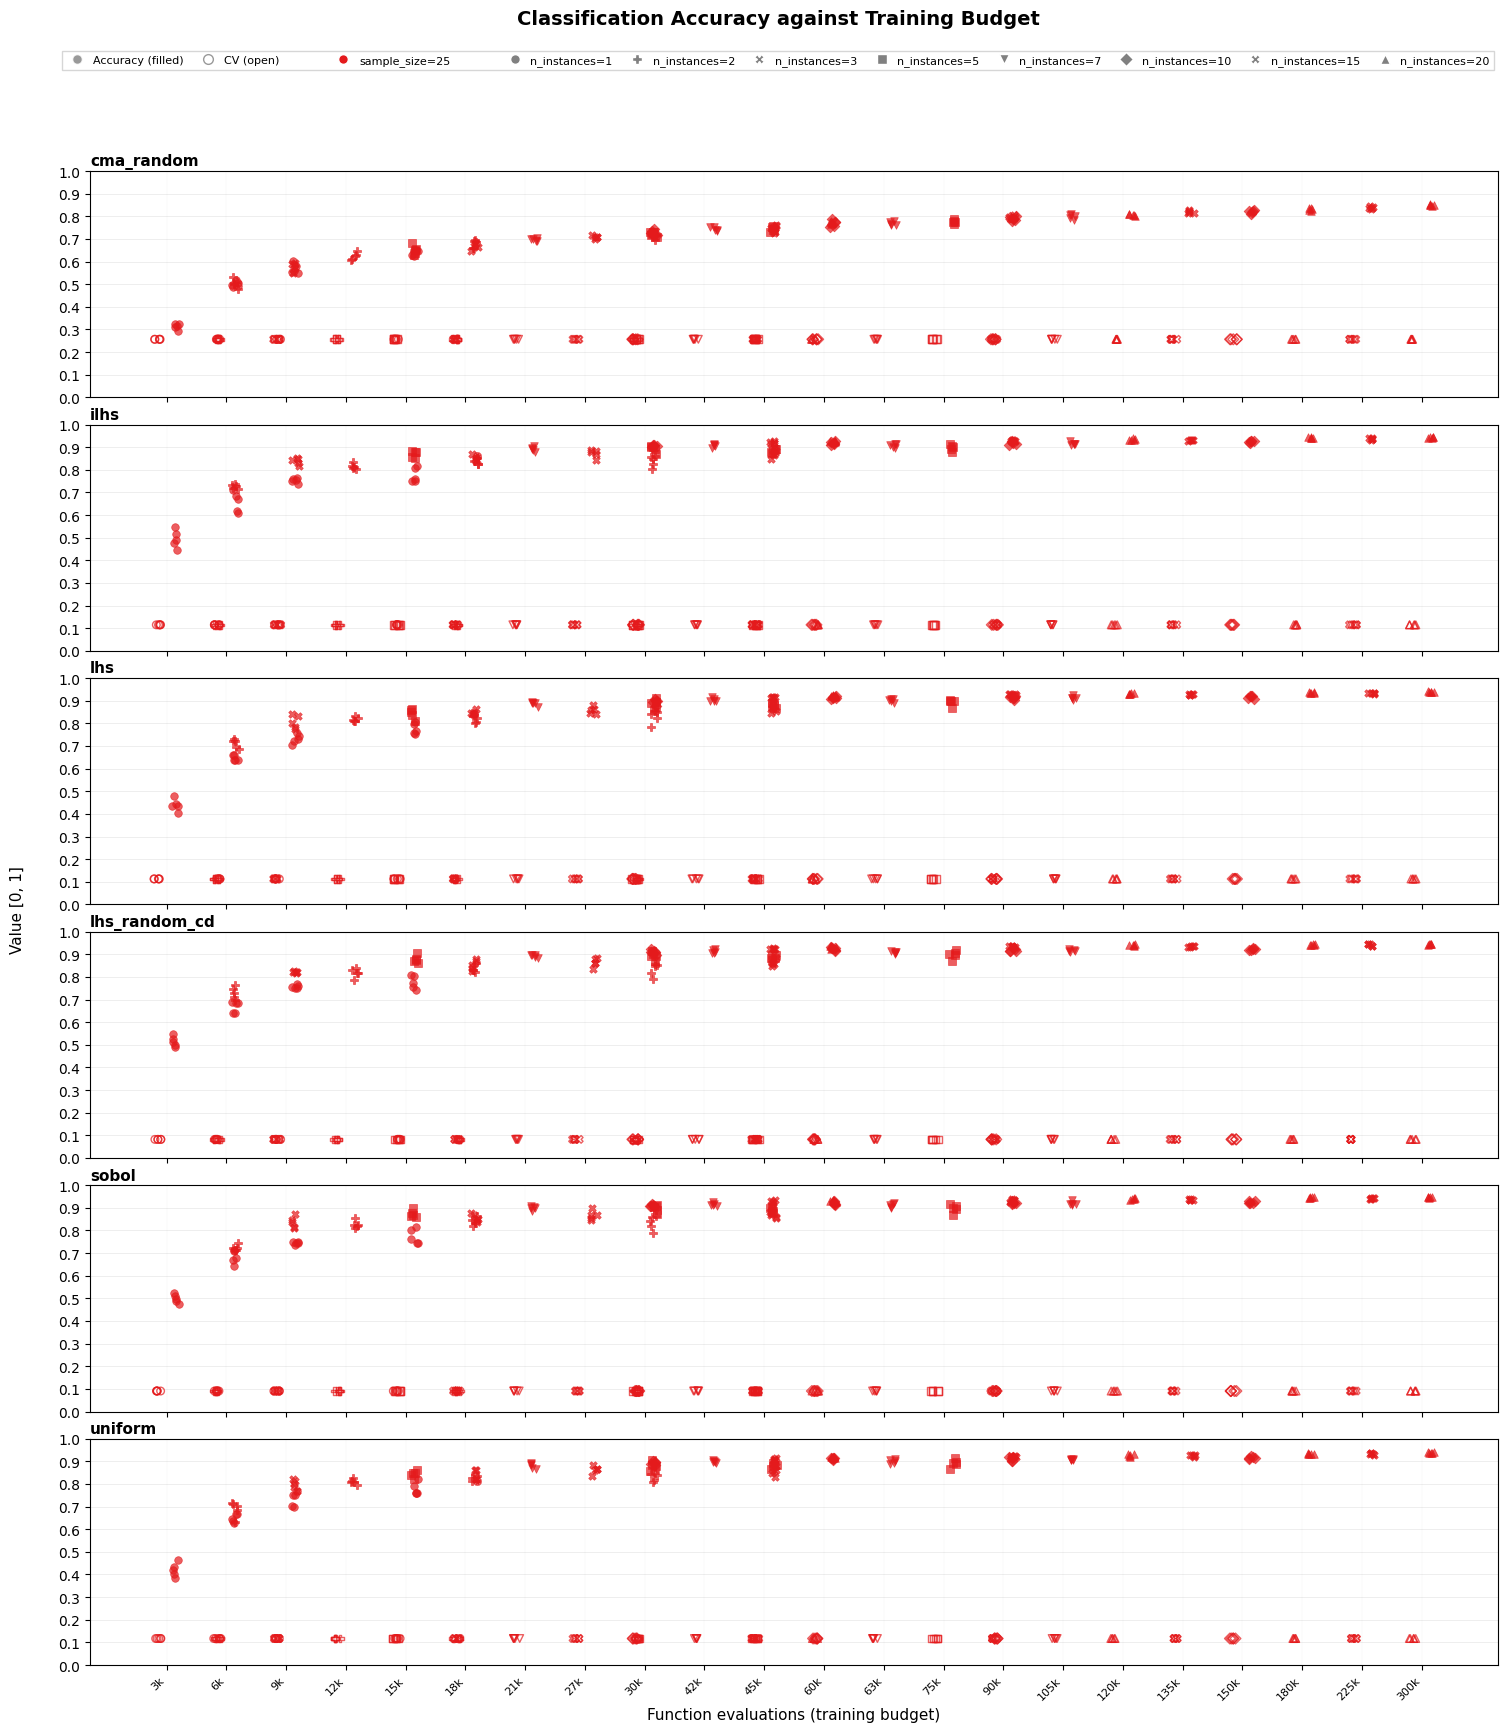

(<Figure size 1600x1800 with 6 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'lhs_random_cd'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [5]:
from ela_table_helper import *
plot_cv_vs_accuracy(df[df.sample_size_per_dim == 25])


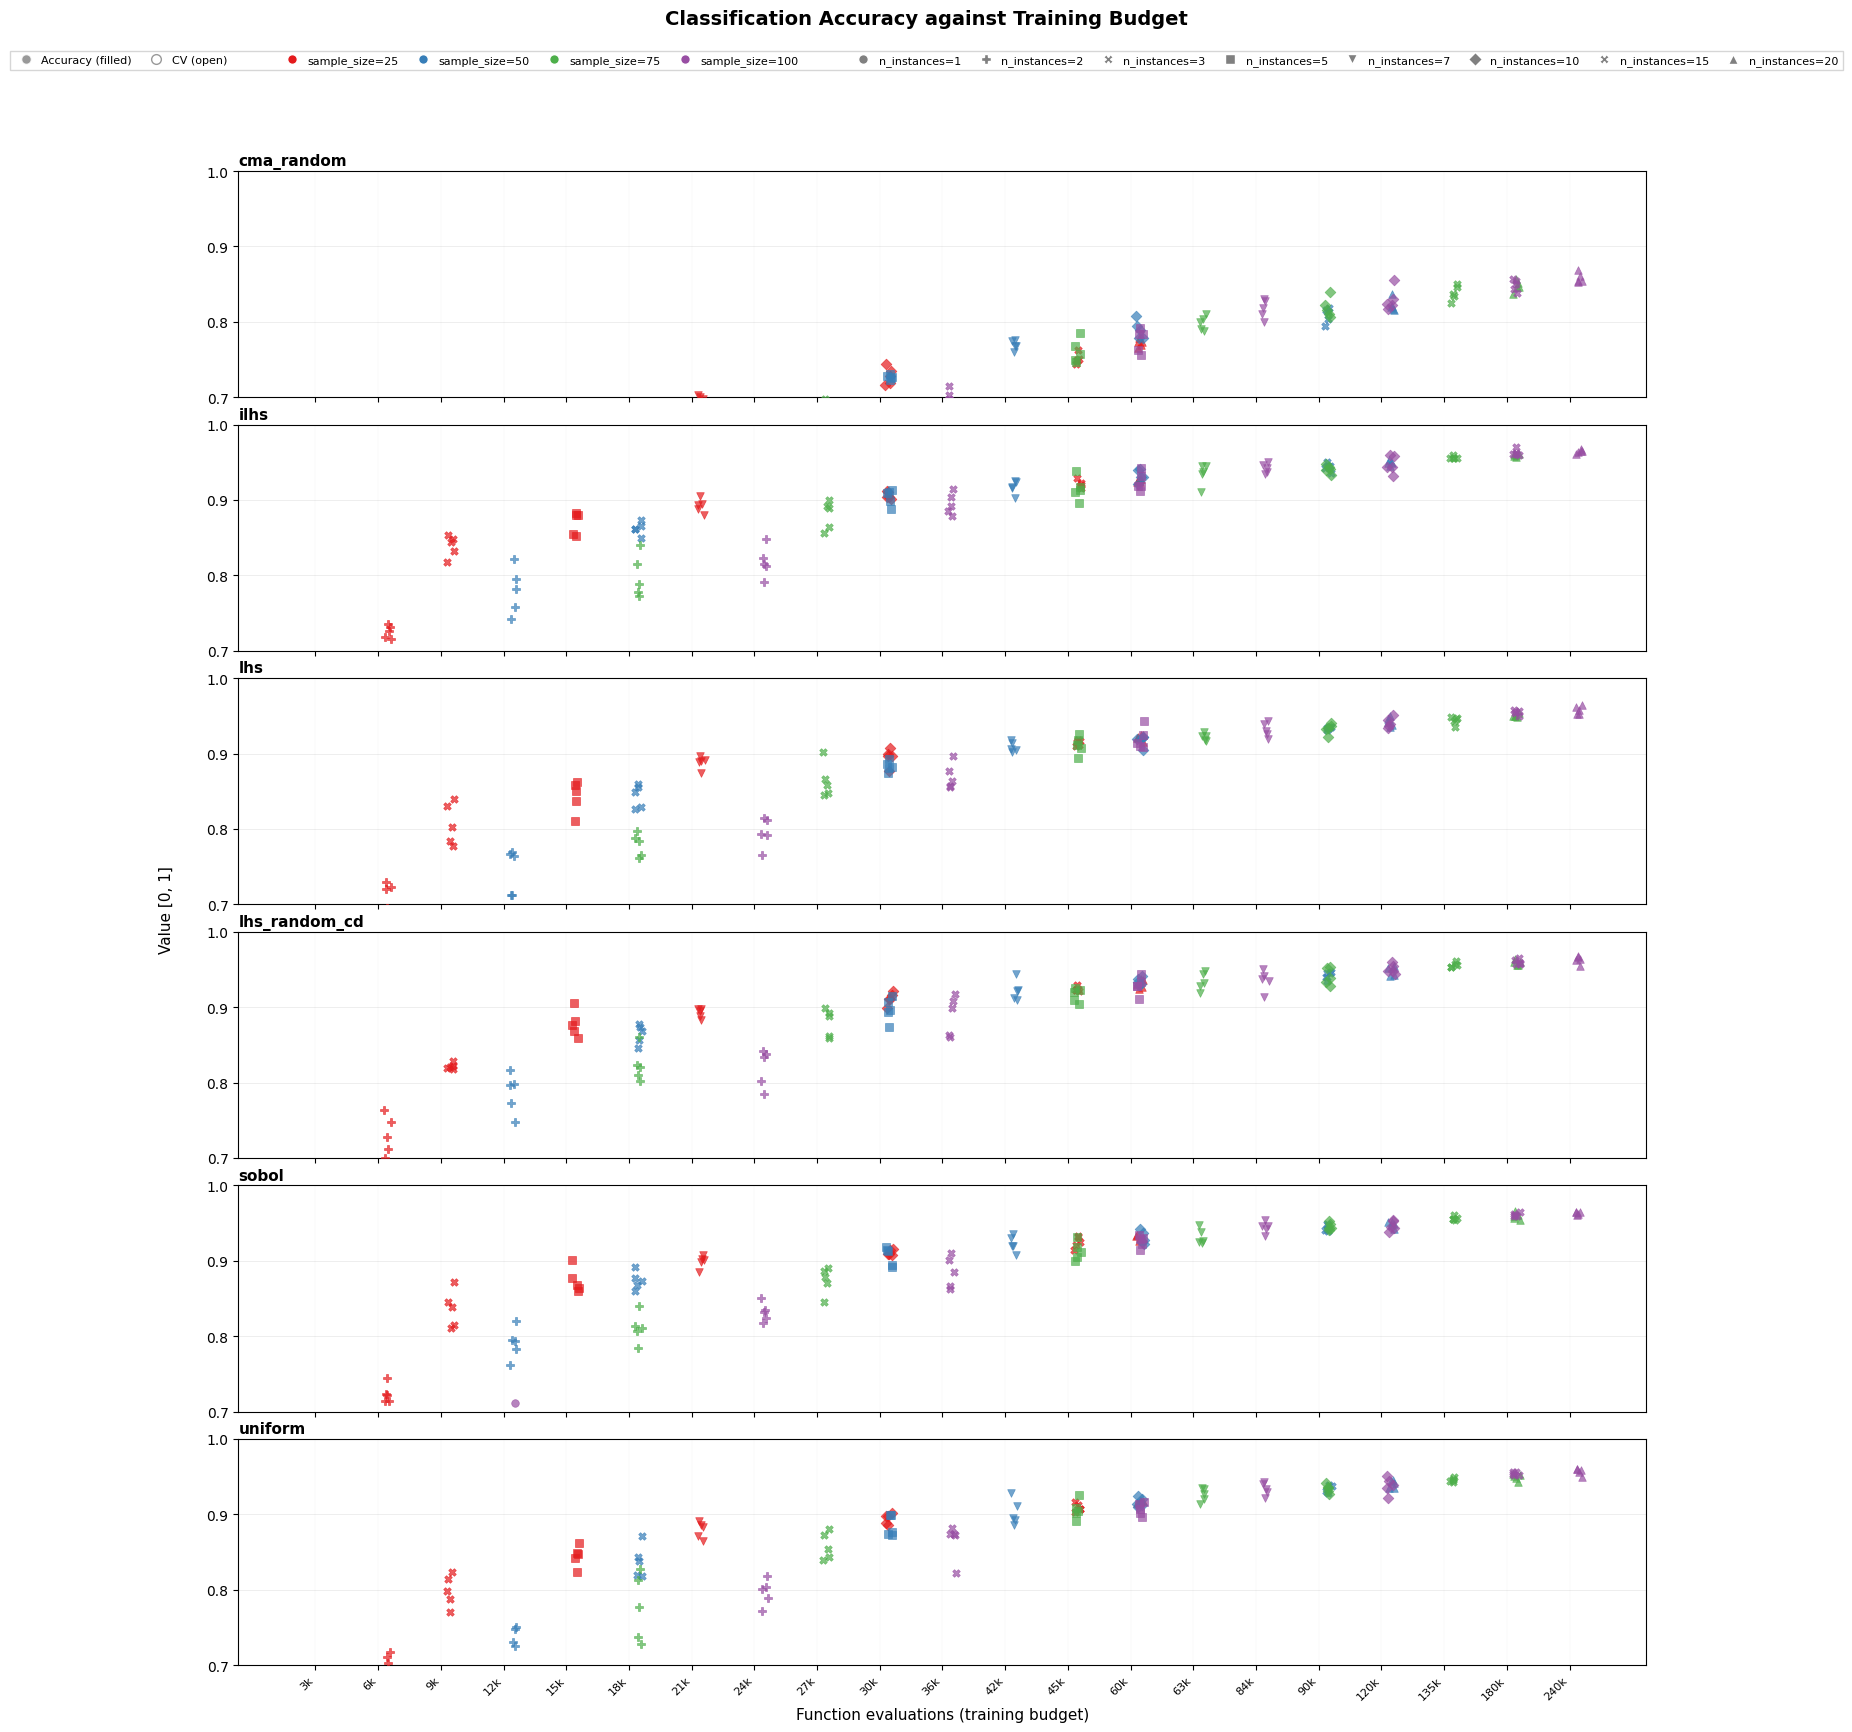

(<Figure size 1600x1800 with 6 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'lhs_random_cd'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [6]:
plot_cv_vs_accuracy(df[df.n_runs_train == 1], ylim=(0.7, 1.0))

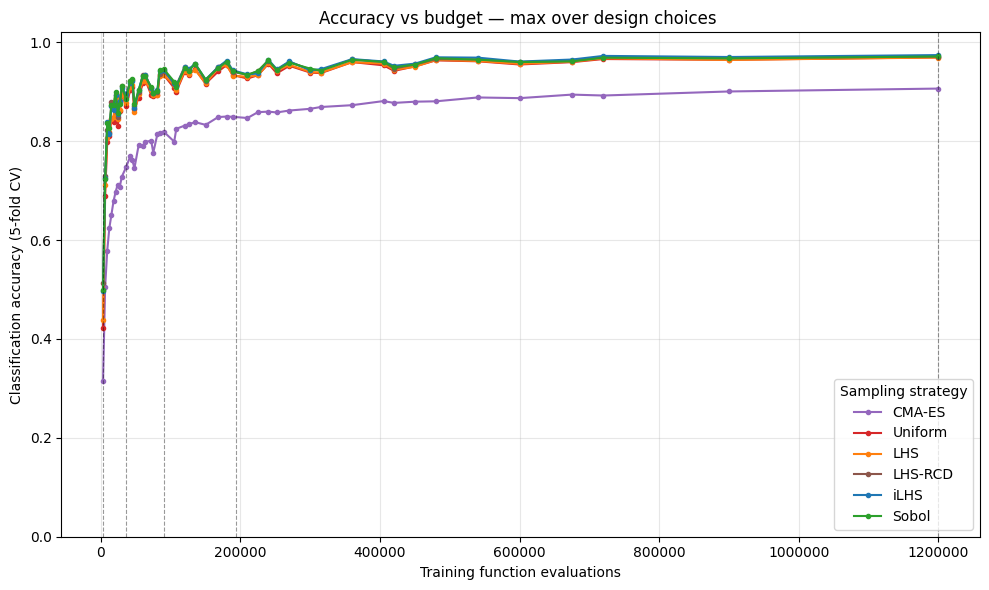

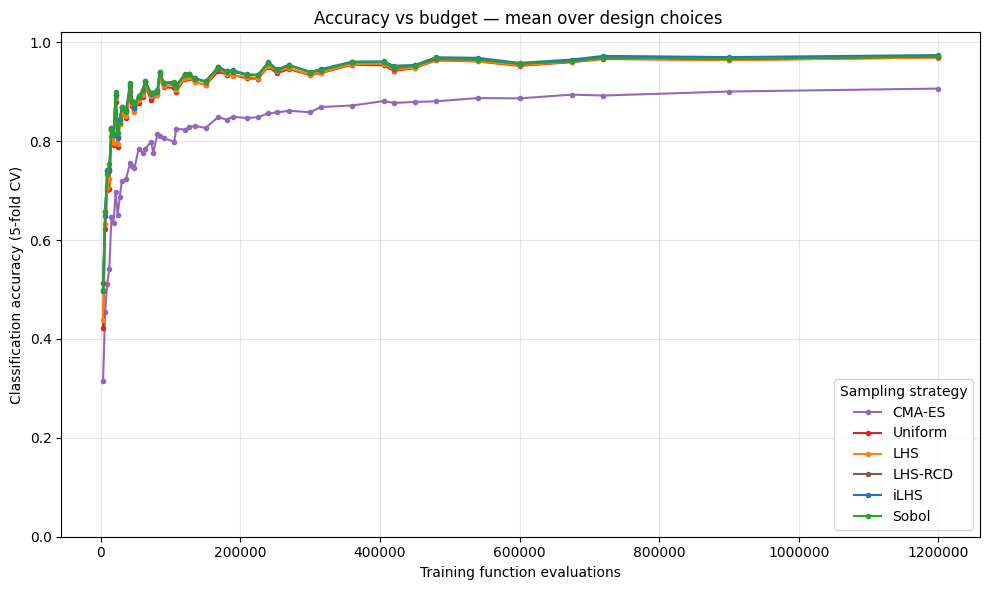

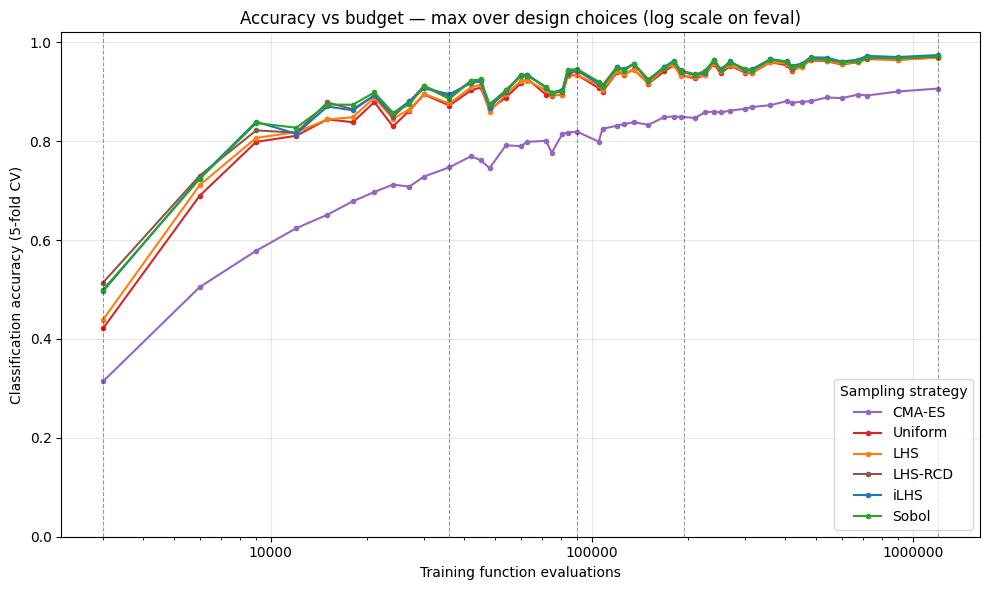

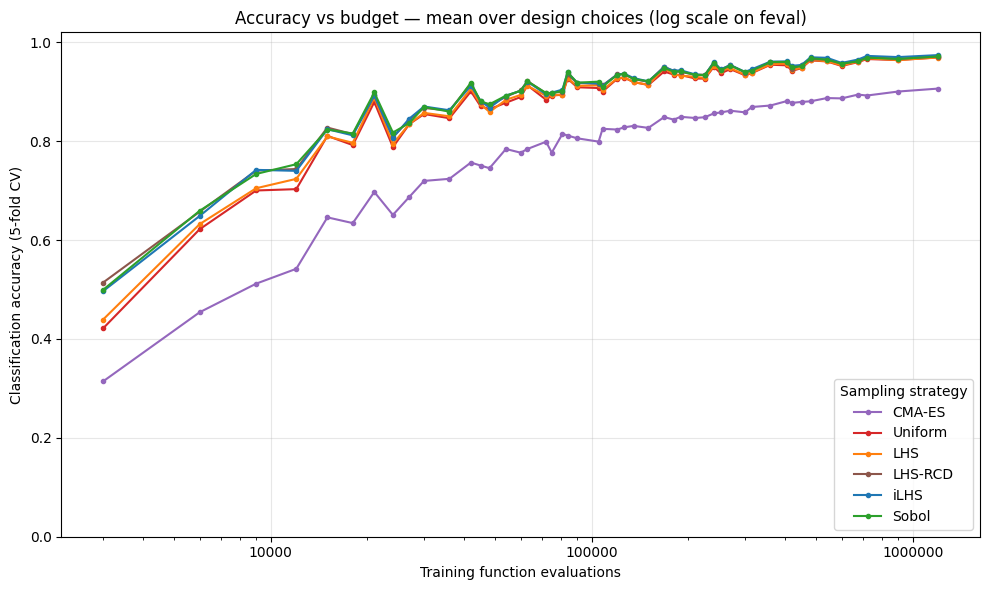

In [7]:
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean")
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4, log_scale=True)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean", log_scale=True)

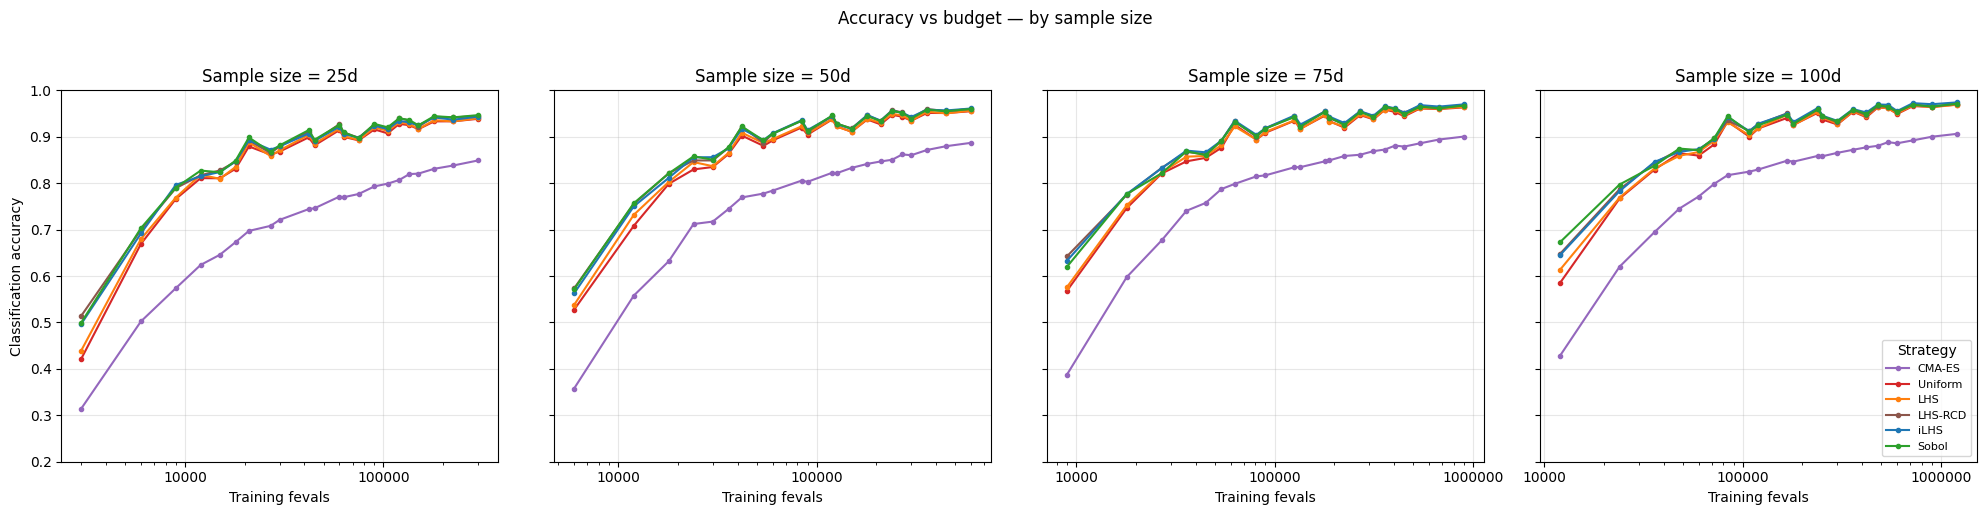

In [8]:
plot_accuracy_vs_budget_faceted(fold_agg_df, ylim = (0.2, 1.0))


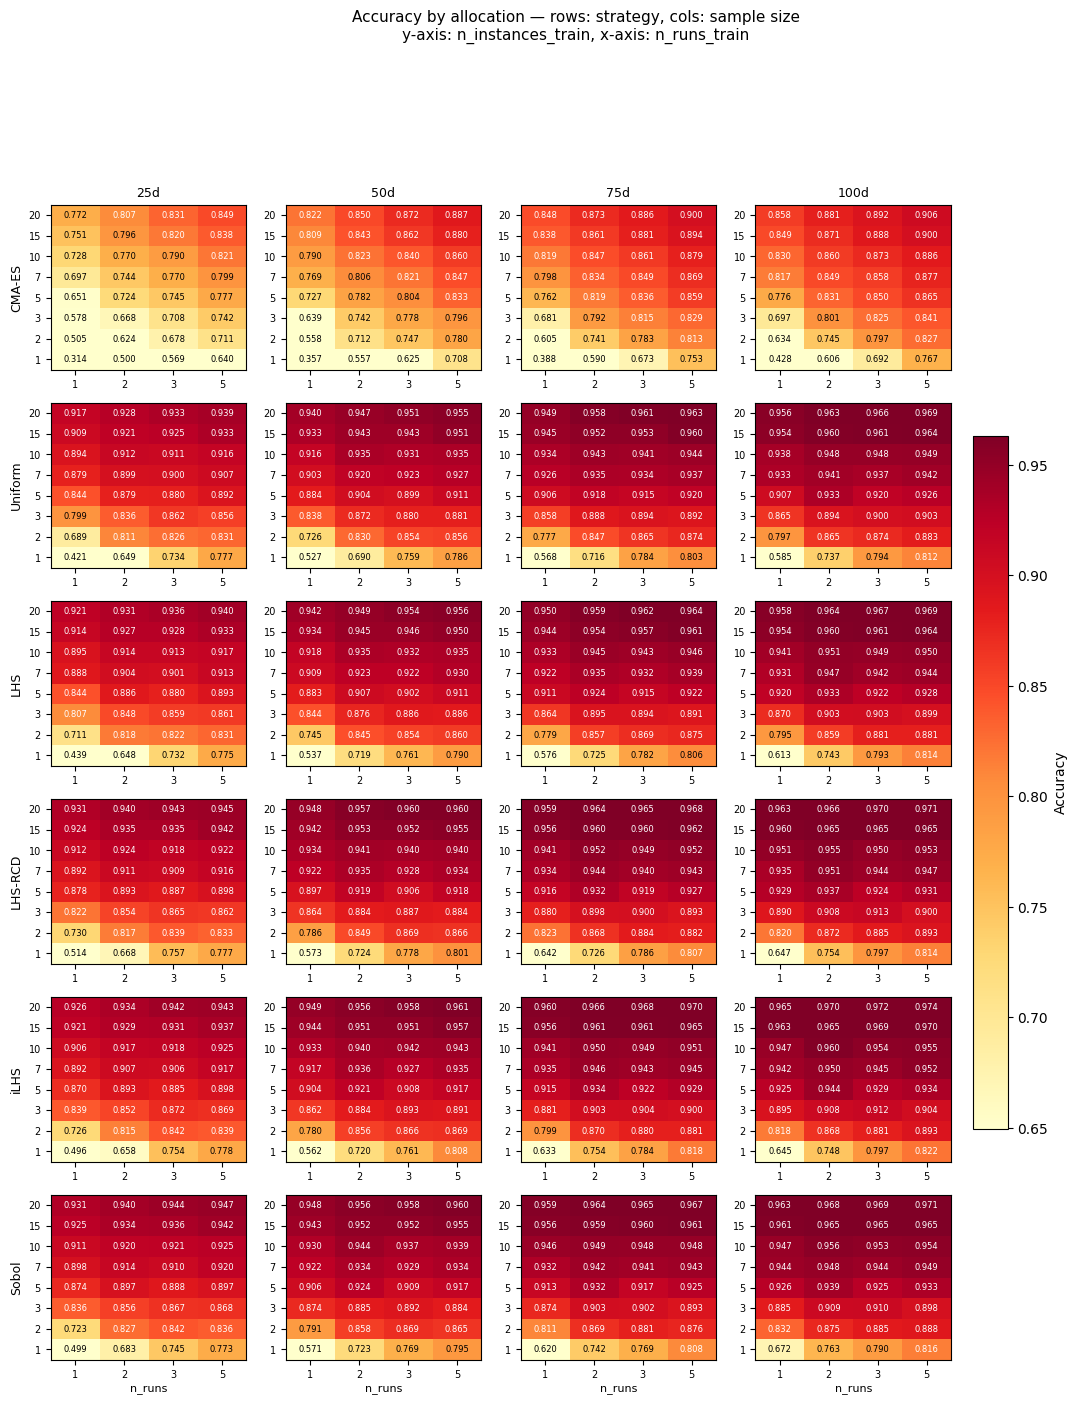

In [9]:
plot_allocation_heatmaps(fold_agg_df)


Budget tiers (4):
  (2999.999, 36000.0]: 216 configs
  (36000.0, 90000.0]: 204 configs
  (90000.0, 194250.0]: 156 configs
  (194250.0, 1200000.0]: 192 configs

          budget_tier              factor factor_label   eta_sq  marginal_range  n_rows  n_levels
  (2999.999, 36000.0]   sampling_strategy     Strategy 0.276379        0.175871     216         6
  (2999.999, 36000.0] sample_size_per_dim  Sample size 0.005608        0.021010     216         4
  (2999.999, 36000.0]   n_instances_train    Instances 0.378495        0.201149     216         6
  (2999.999, 36000.0]        n_runs_train         Runs 0.029451        0.045469     216         4
   (36000.0, 90000.0]   sampling_strategy     Strategy 0.684802        0.121600     204         6
   (36000.0, 90000.0] sample_size_per_dim  Sample size 0.011757        0.017280     204         4
   (36000.0, 90000.0]   n_instances_train    Instances 0.218751        0.101595     204         8
   (36000.0, 90000.0]        n_runs_train         Runs 0

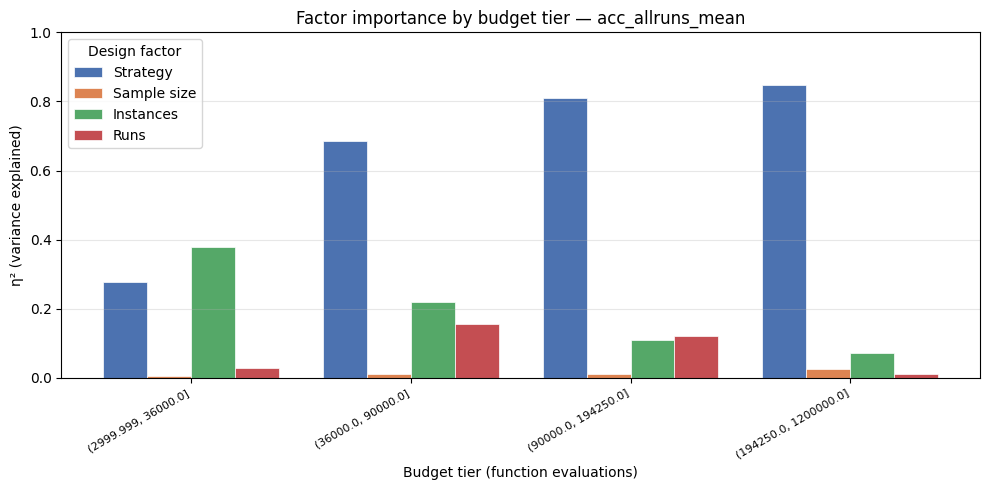

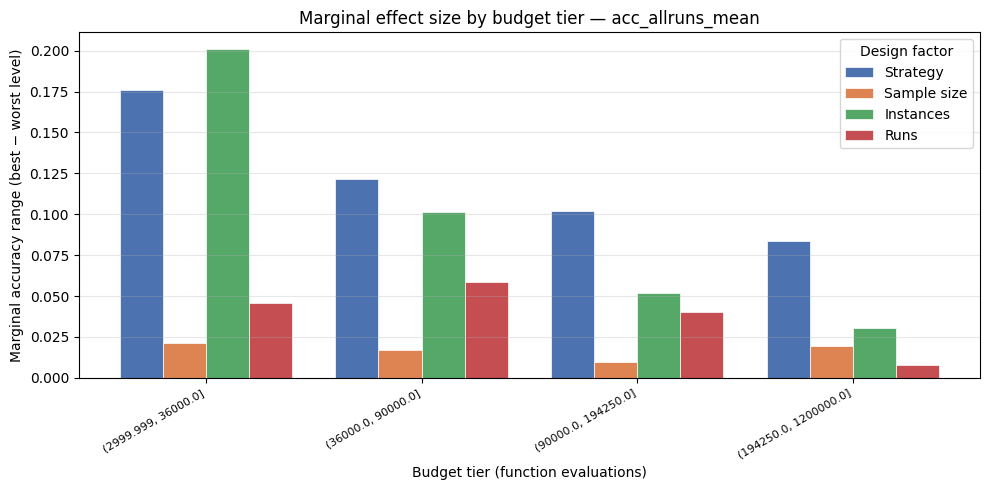

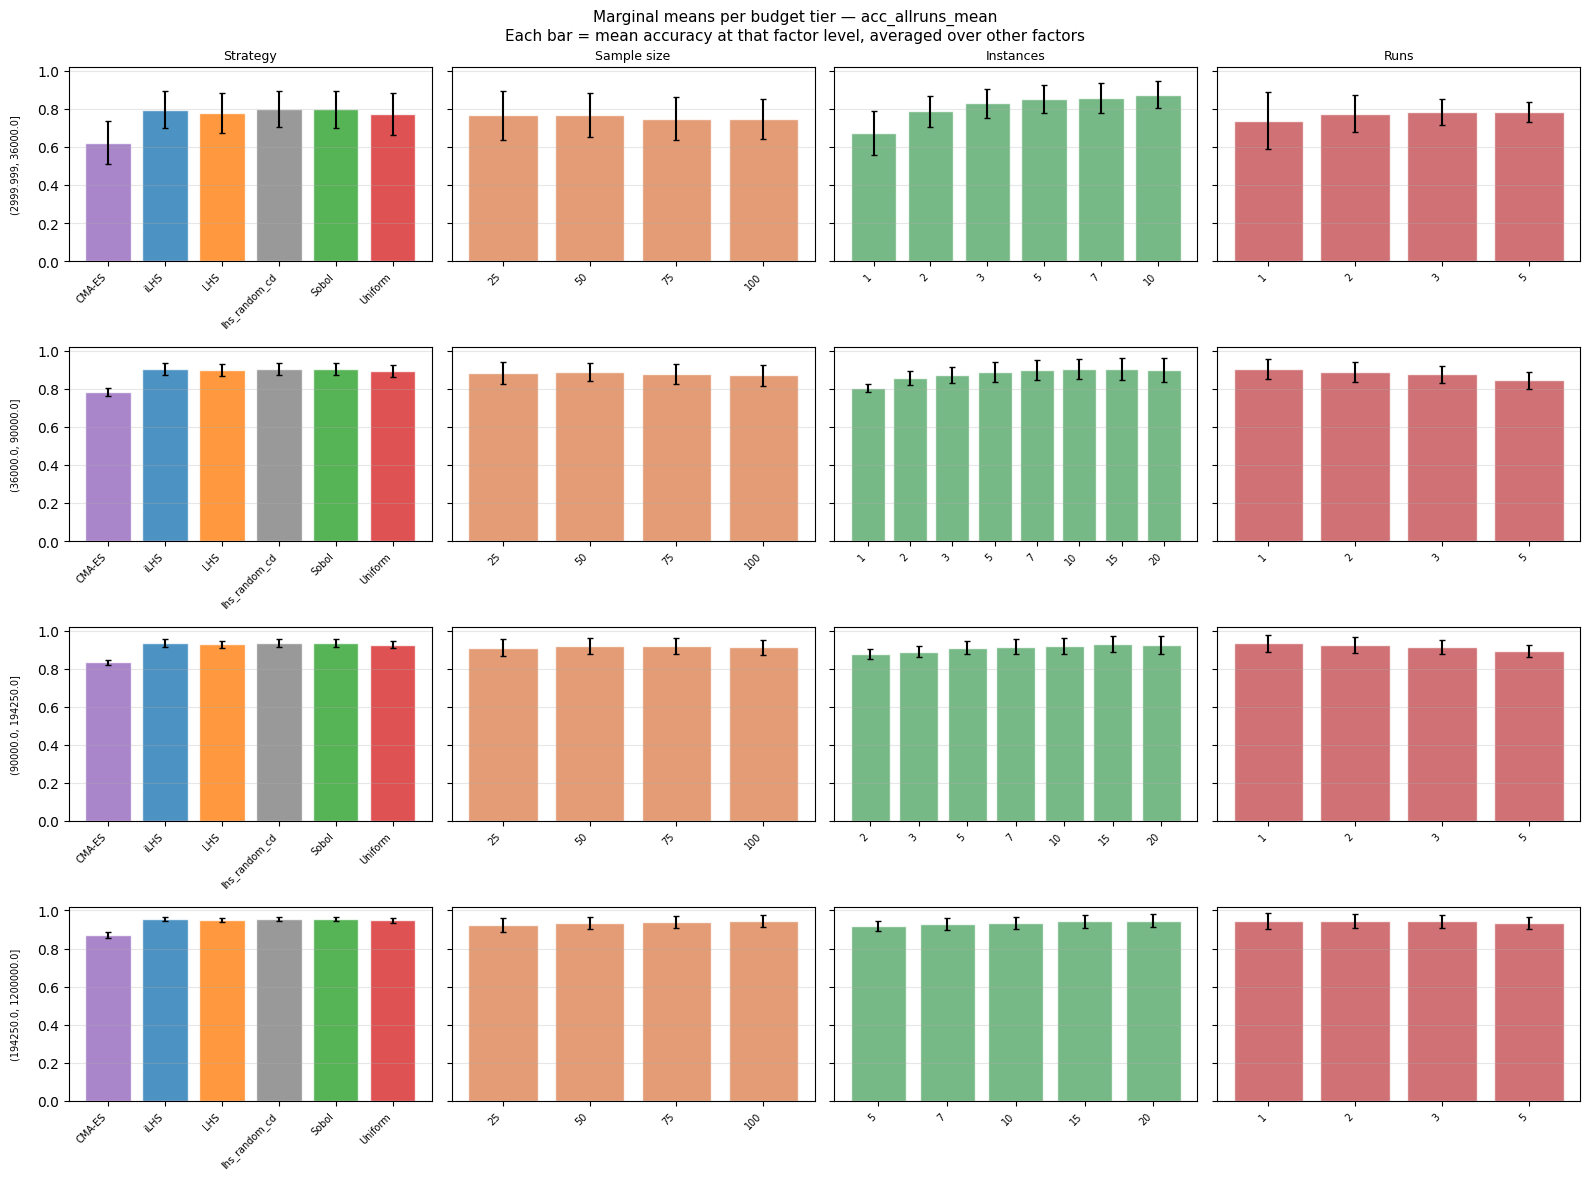

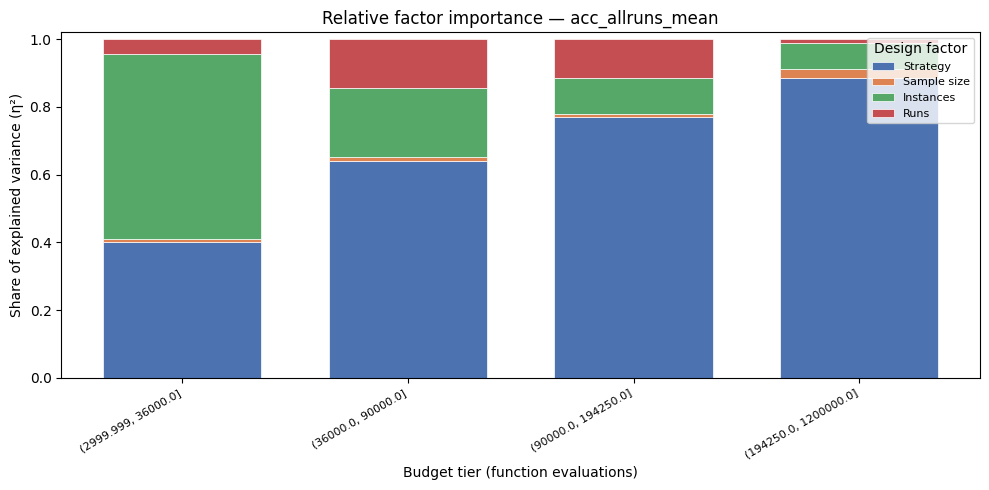

In [10]:
from rq2_factor_importance import *
imp_df = run_all(fold_agg_df, metric="acc_allruns_mean")

Pair-level data (24 strategy×size combos):
sampling_strategy  sample_size_per_dim       cv  acc_mean  acc_std  n_configs
       cma_random                   25 0.342458  0.709916 0.117193         32
       cma_random                   50 0.345849  0.766421 0.113752         32
       cma_random                   75 0.365430  0.796087 0.108124         32
       cma_random                  100 0.396974  0.808637 0.102075         32
             ilhs                   25 0.201762  0.863637 0.095047         32
             ilhs                   50 0.162415  0.890684 0.085245         32
             ilhs                   75 0.144699  0.905463 0.075274         32
             ilhs                  100 0.133538  0.911717 0.074522         32
              lhs                   25 0.235138  0.853998 0.103501         32
              lhs                   50 0.187575  0.880855 0.088564         32
              lhs                   75 0.167419  0.894747 0.083364         32
              lhs    

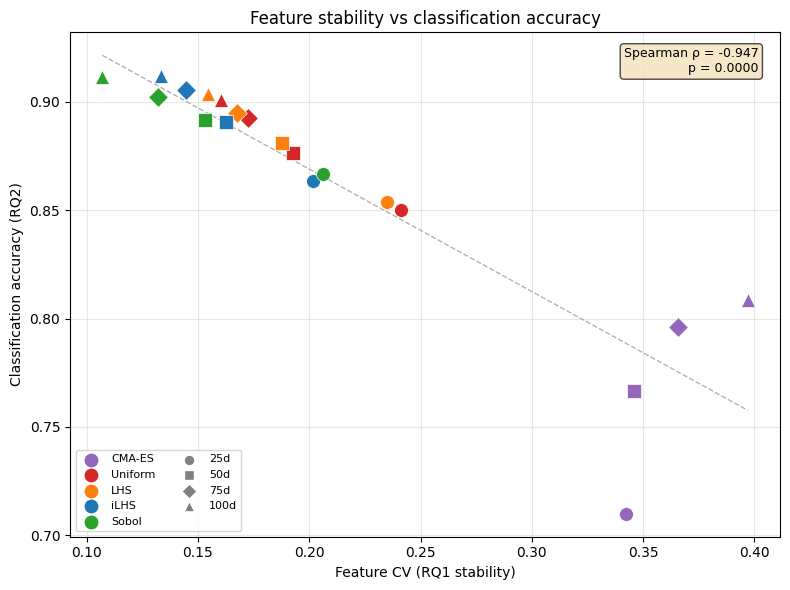

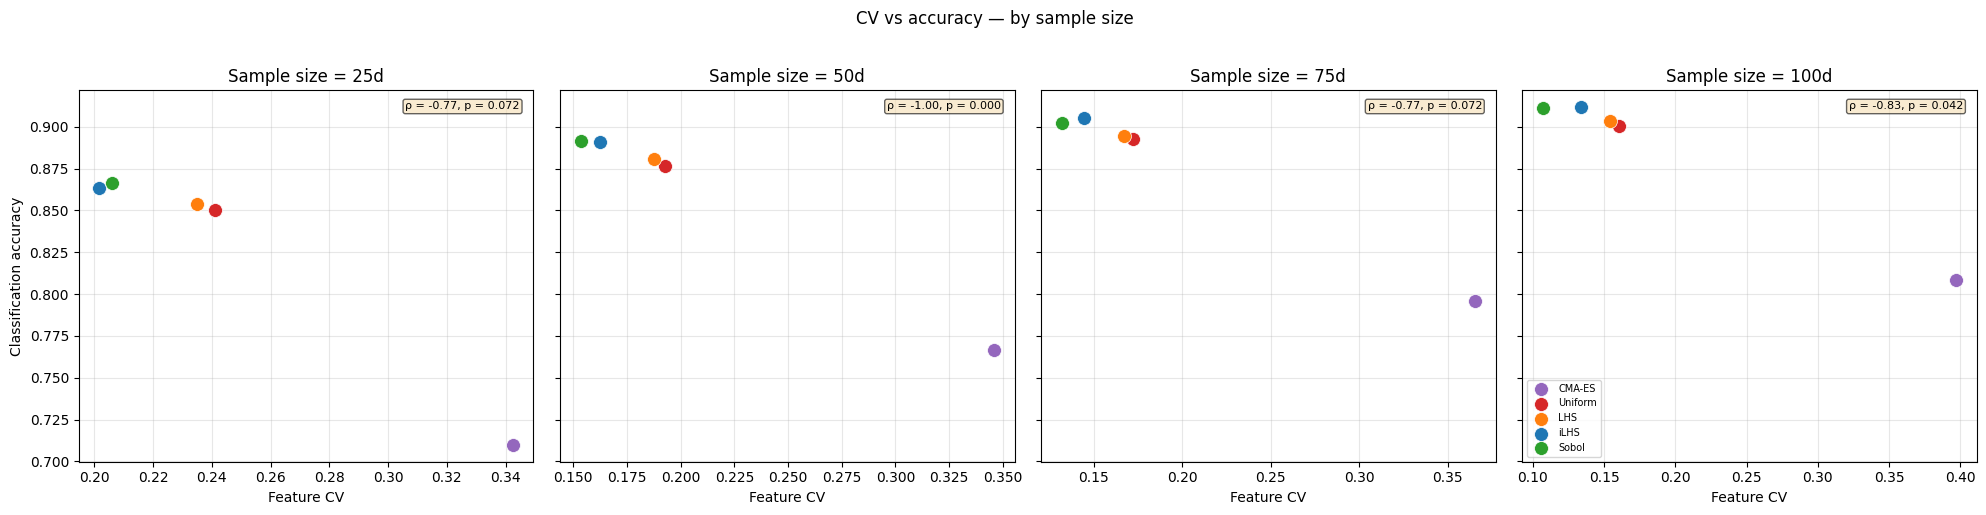

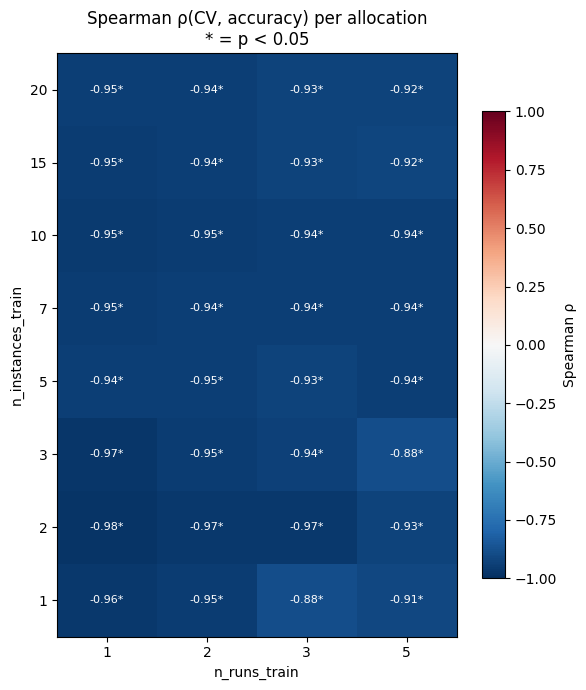


Partial correlation analysis:
        analysis     controlling_for   n  spearman_rho      p_value
             Raw                   — 768     -0.481583 7.680166e-46
         Partial sample_size_per_dim 768     -0.373564 7.651370e-27
         Partial       n_feval_train 768     -0.391715 1.433796e-29
 Within size=25d        (stratified) 192     -0.381480 4.780343e-08
 Within size=50d        (stratified) 192     -0.376308 7.478750e-08
 Within size=75d        (stratified) 192     -0.350199 6.377967e-07
Within size=100d        (stratified) 192     -0.346595 8.448535e-07



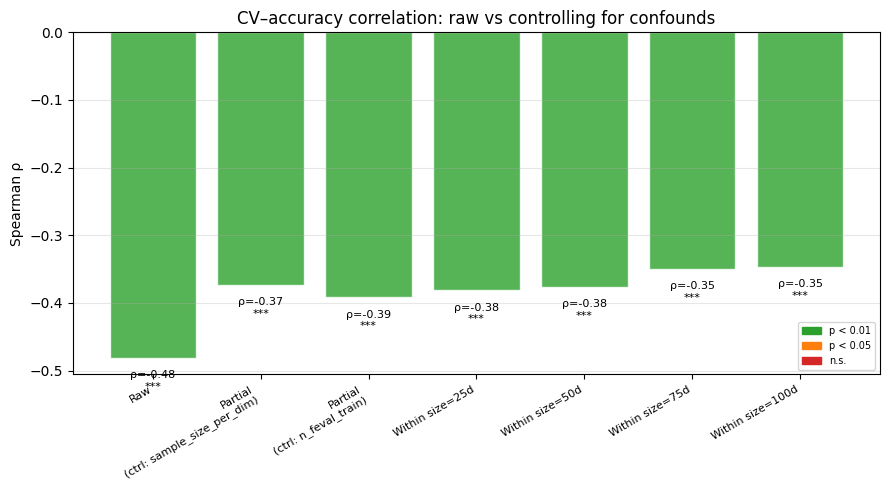

Full correlation summary:
      level level_value   n  spearman_rho      p_value
     global         all 768     -0.481583 7.680166e-46
sample_size          25 192     -0.381480 4.780343e-08
sample_size          50 192     -0.376308 7.478750e-08
sample_size          75 192     -0.350199 6.377967e-07
sample_size         100 192     -0.346595 8.448535e-07
 allocation  1inst_1run  24     -0.963478 4.486612e-14
 allocation  1inst_2run  24     -0.947826 2.109019e-12
 allocation  1inst_3run  24     -0.883478 1.070739e-08
 allocation  1inst_5run  24     -0.912174 5.480155e-10
 allocation  2inst_1run  24     -0.978261 1.597033e-16
 allocation  2inst_2run  24     -0.966957 1.516437e-14
 allocation  2inst_3run  24     -0.968696 8.434171e-15
 allocation  2inst_5run  24     -0.926957 7.741111e-11
 allocation  3inst_1run  24     -0.973043 1.661336e-15
 allocation  3inst_2run  24     -0.950435 1.214363e-12
 allocation  3inst_3run  24     -0.937391 1.492039e-11
 allocation  3inst_5run  24     -0.8834

(          level  level_value    n  spearman_rho       p_value
 0        global          all  768     -0.481583  7.680166e-46
 1   sample_size           25  192     -0.381480  4.780343e-08
 2   sample_size           50  192     -0.376308  7.478750e-08
 3   sample_size           75  192     -0.350199  6.377967e-07
 4   sample_size          100  192     -0.346595  8.448535e-07
 5    allocation   1inst_1run   24     -0.963478  4.486612e-14
 6    allocation   1inst_2run   24     -0.947826  2.109019e-12
 7    allocation   1inst_3run   24     -0.883478  1.070739e-08
 8    allocation   1inst_5run   24     -0.912174  5.480155e-10
 9    allocation   2inst_1run   24     -0.978261  1.597033e-16
 10   allocation   2inst_2run   24     -0.966957  1.516437e-14
 11   allocation   2inst_3run   24     -0.968696  8.434171e-15
 12   allocation   2inst_5run   24     -0.926957  7.741111e-11
 13   allocation   3inst_1run   24     -0.973043  1.661336e-15
 14   allocation   3inst_2run   24     -0.950435  1.214

In [11]:
from rq2_cv_accuracy import *
run_all(fold_agg_df, cv_col="cv_instance_median_mean",
                               acc_col="acc_allruns_mean")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'lhs_random_cd', 'sobol', 'uniform']

Saturation curves for Strategy ...


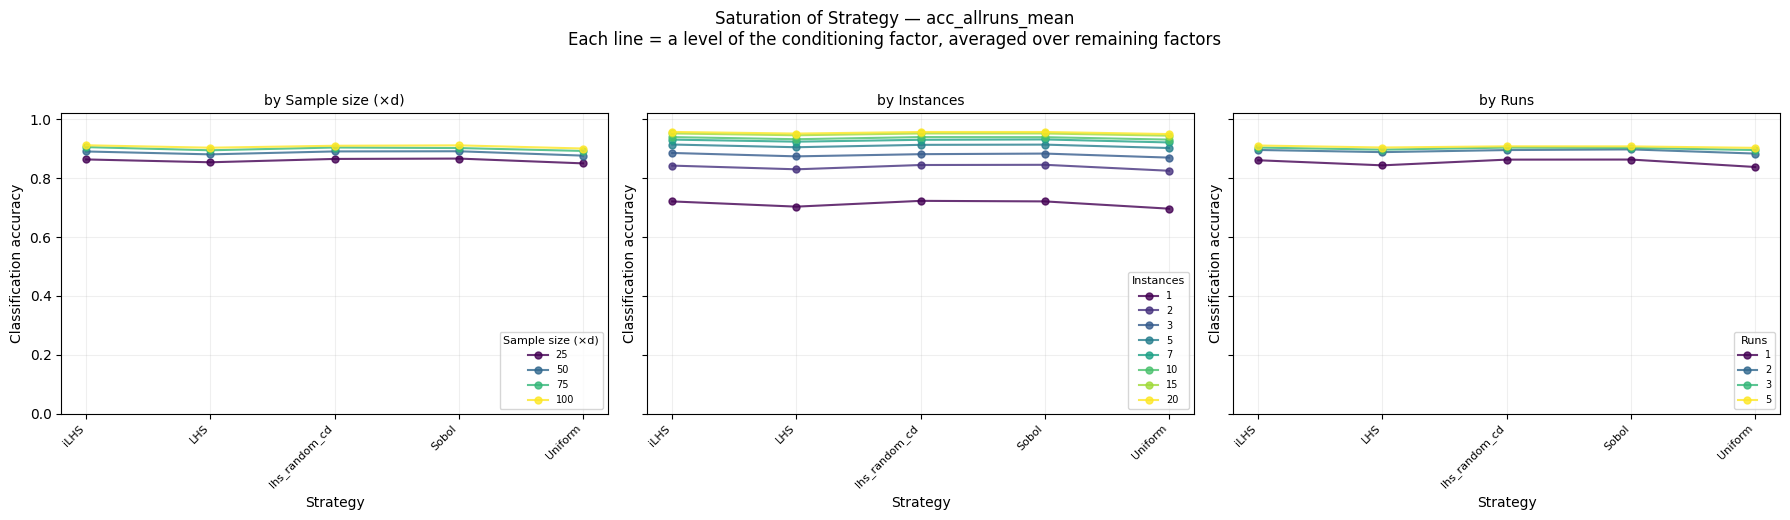

Saturation curves for Sample size (×d) ...


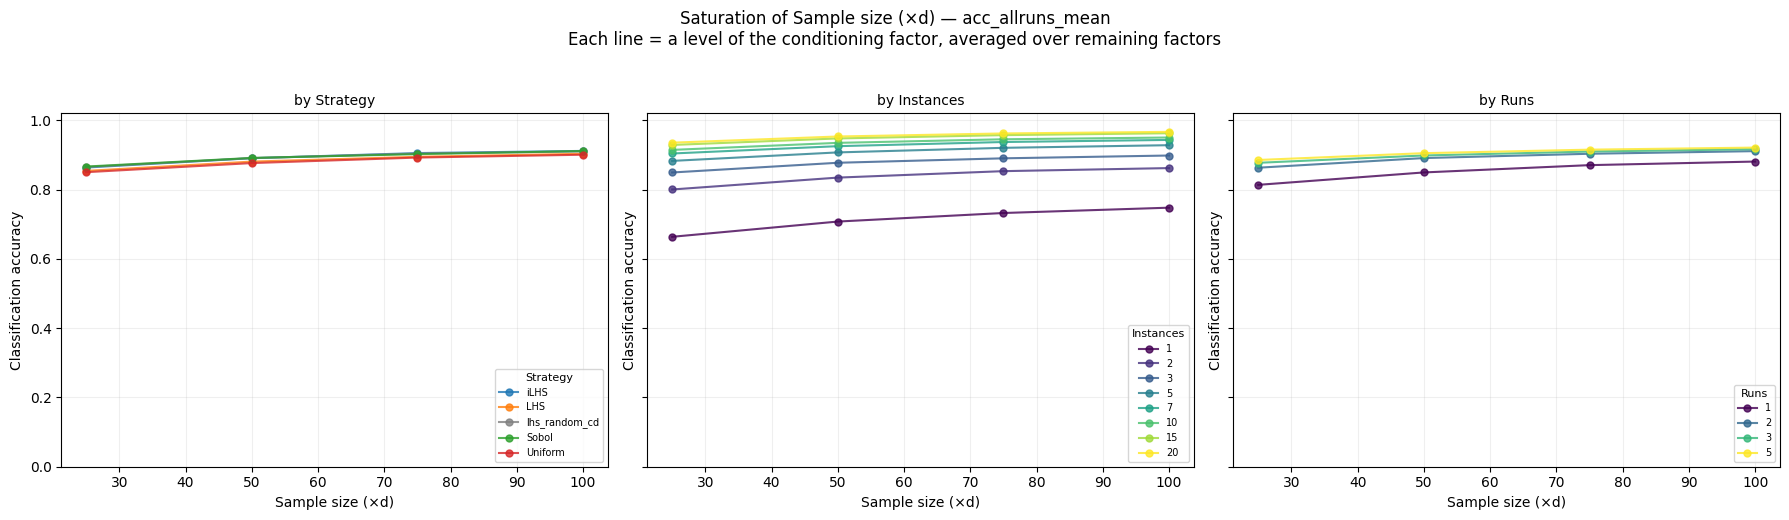

Saturation curves for Instances ...


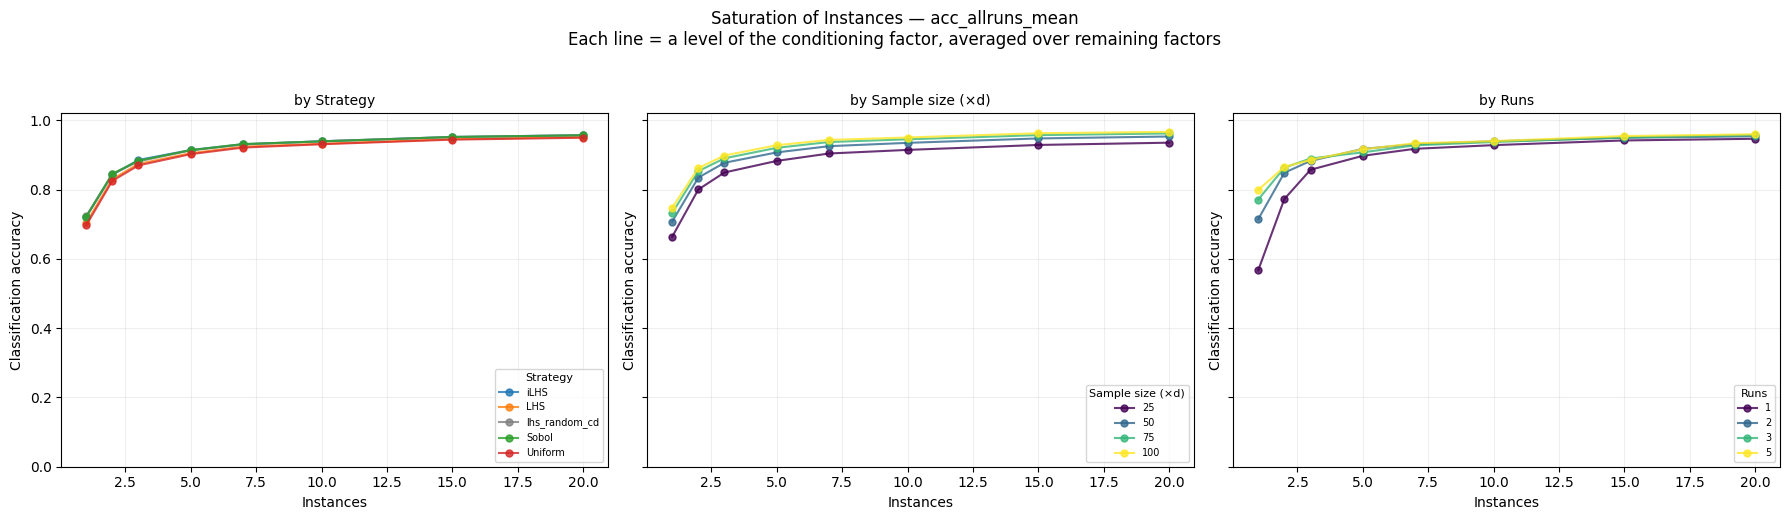

Saturation curves for Runs ...


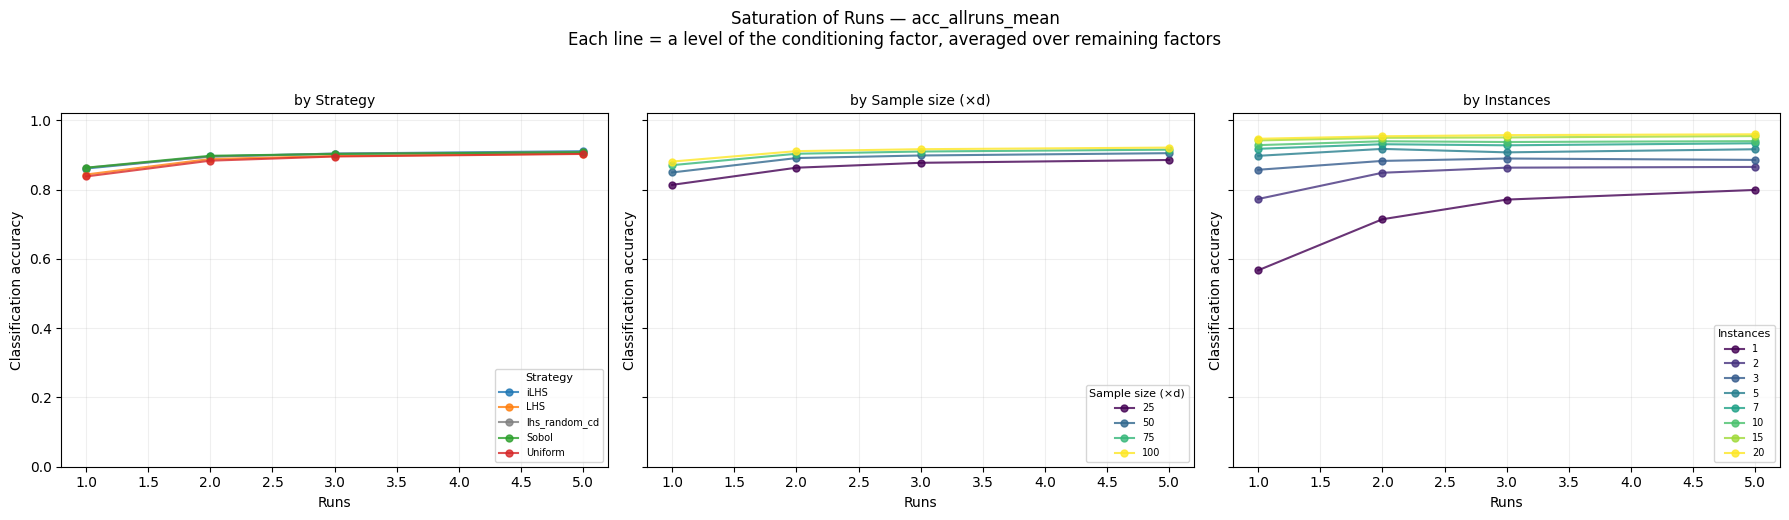

Marginal gains per step ...
          factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
Sample size (×d)          25        50   0.026122    0.047533          54.955287
Sample size (×d)          50        75   0.013756    0.047533          28.939555
Sample size (×d)          75       100   0.007655    0.047533          16.105157
       Instances           1         2   0.124654    0.241450          51.627084
       Instances           2         3   0.041303    0.241450          17.106398
       Instances           3         5   0.030864    0.241450          12.782720
       Instances           5         7   0.017845    0.241450           7.390808
       Instances           7        10   0.008691    0.241450           3.599377
       Instances          10        15   0.012839    0.241450           5.317419
       Instances          15        20   0.005254    0.241450           2.176193
            Runs           1         2   0.038474    0.053102          72.454070


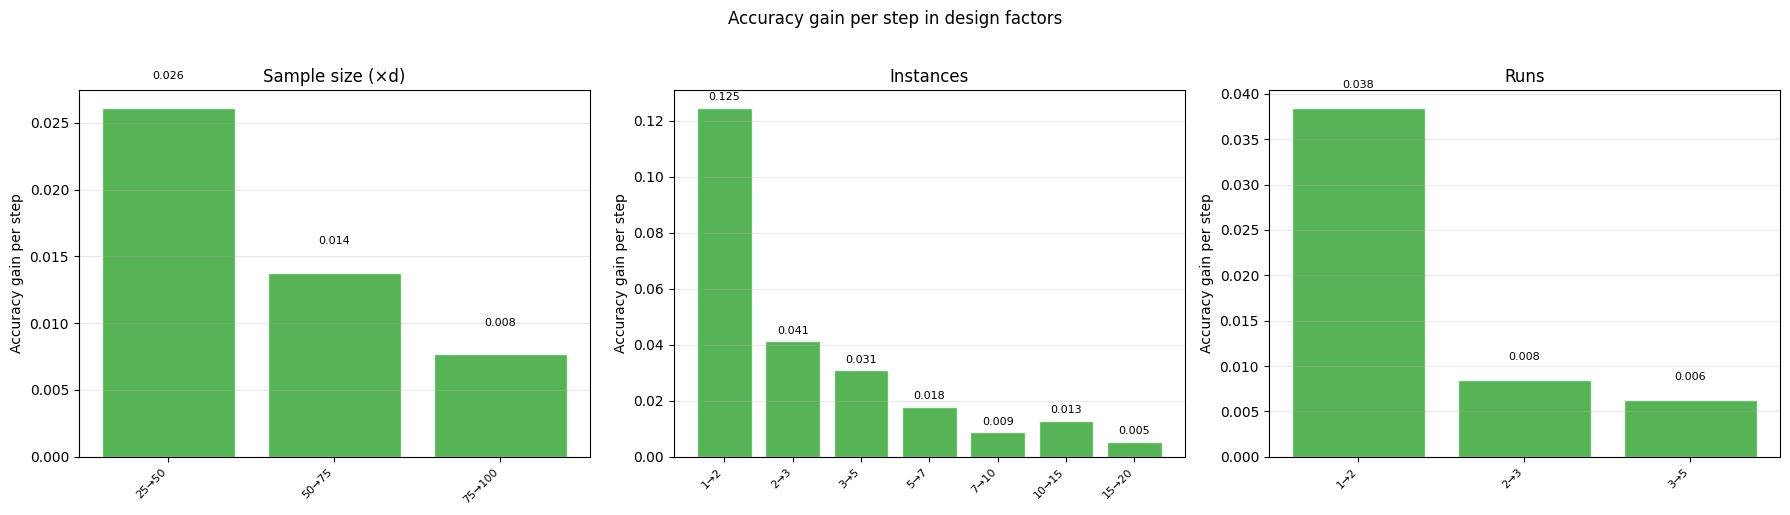

In [12]:
from rq2_saturation_curves import *

# All four factors + marginal gains table
gains_df = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")

In [13]:
from rq2_rf_impurity_importance import *
input_df = fold_agg_df[fold_agg_df["sampling_strategy"] != "cma_random"]
results_imp, summary_imp, metrics_df = run_stratified_impurity_importance(
    input_df,
    hyperparams=["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
    target="acc_allruns_mean",
    budget_col="n_feval_train",
    n_budget_tiers=4,
)

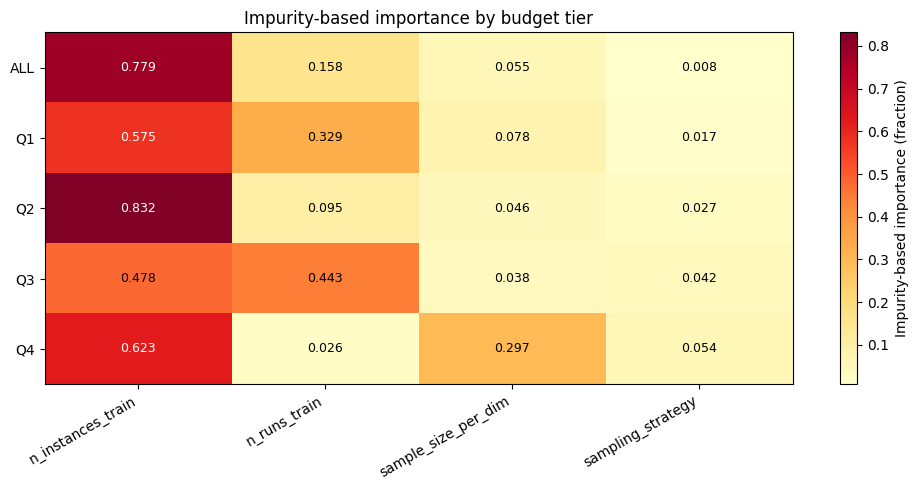

In [14]:
plot_importance_heatmap(summary_imp)
plt.show()


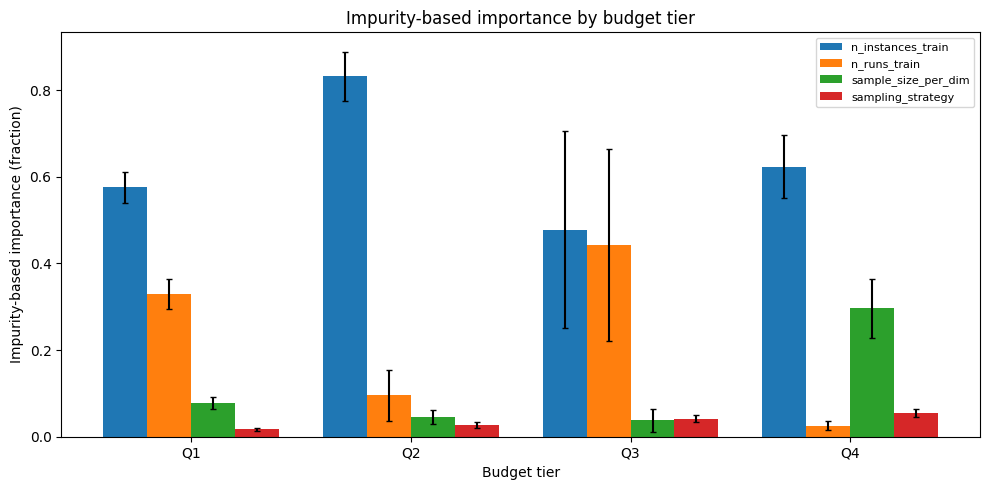

In [15]:
plot_importance_bars(results_imp)
plt.show()


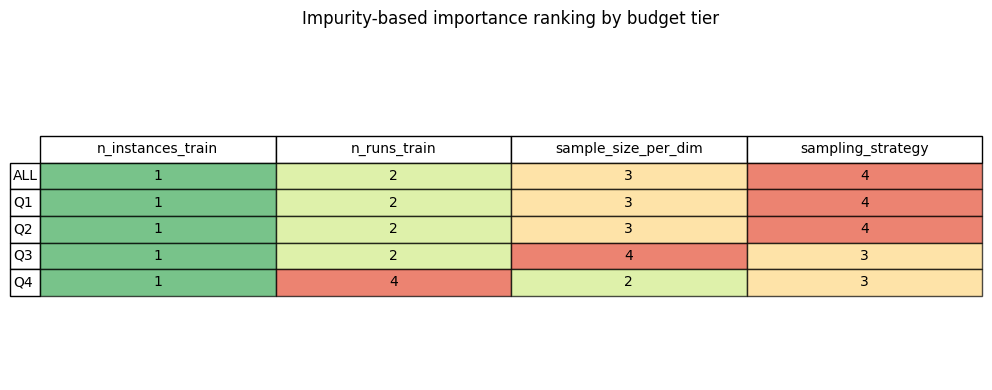

In [16]:
plot_rank_table(results_imp)
plt.show()


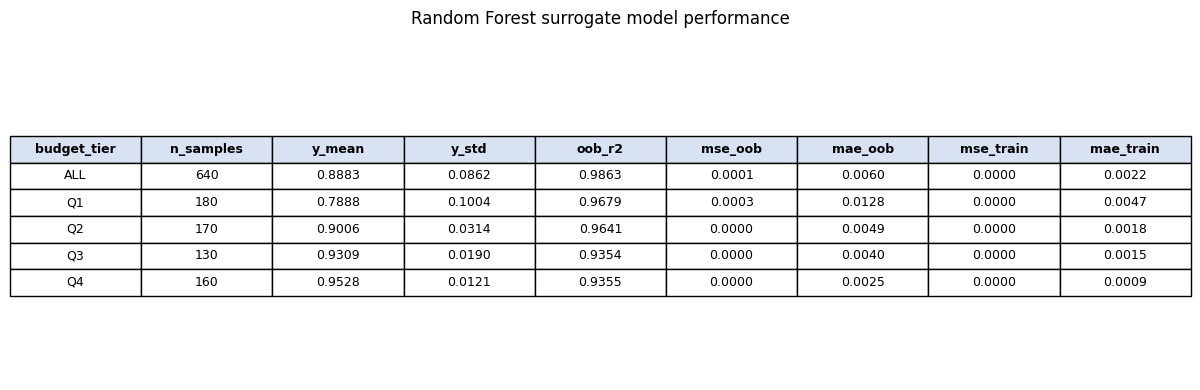

In [17]:
plot_metrics_table(metrics_df)
plt.show()


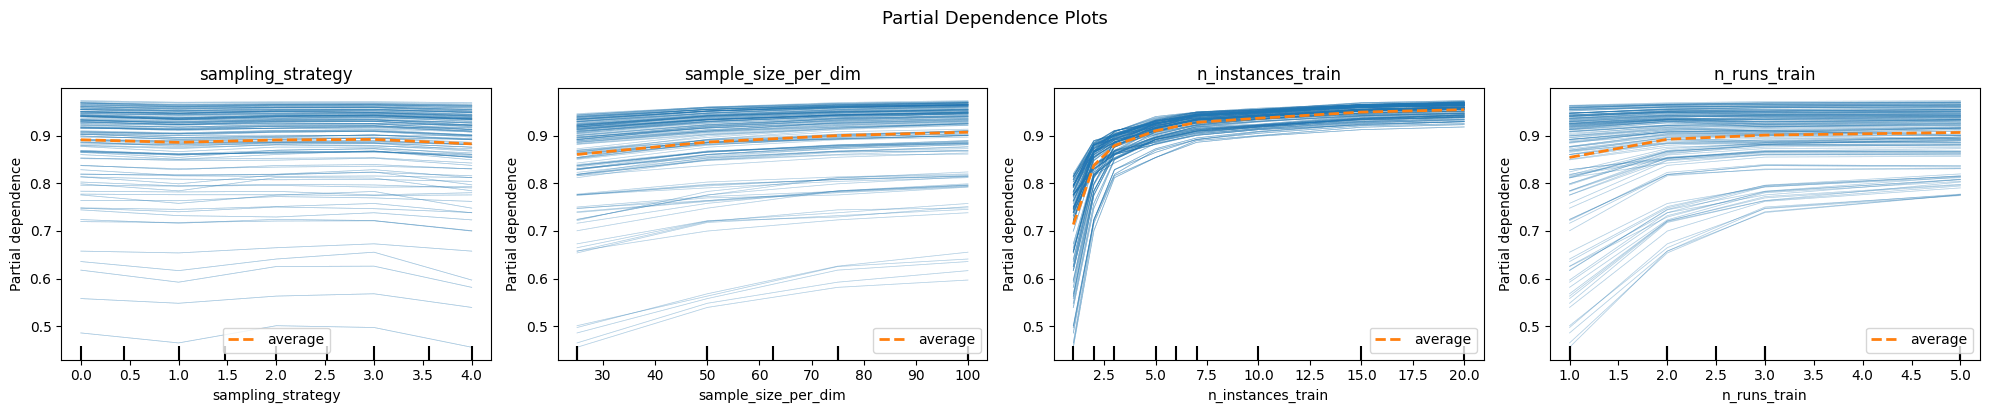

In [18]:
plot_pdp_individual(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], target="acc_allruns_mean")
plt.show()

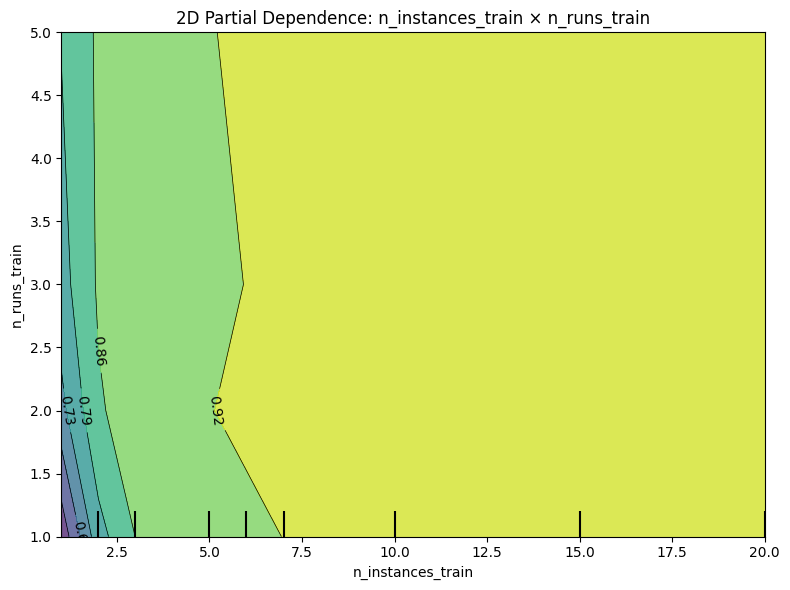

In [19]:
plot_pdp_2d(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"))
plt.show()

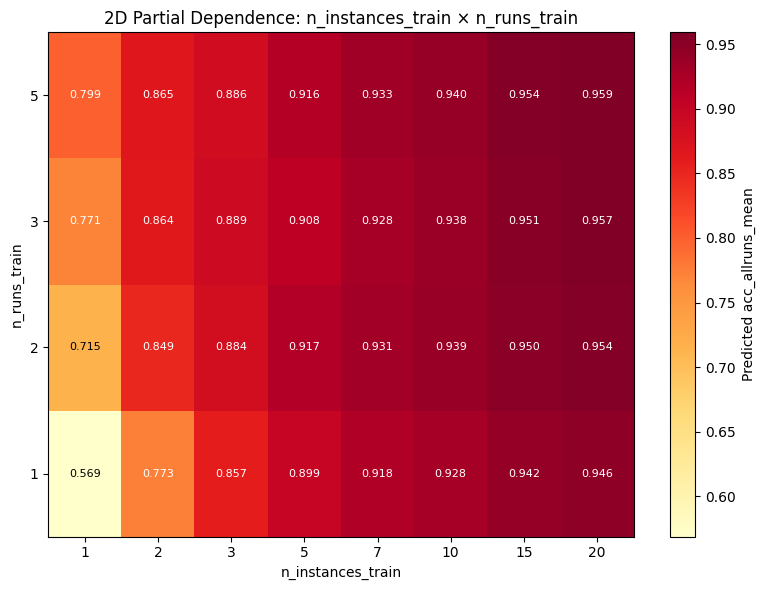

In [20]:
plot_pdp_2d_heatmap(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"),
            target="acc_allruns_mean",
            annotate=True)
plt.show()

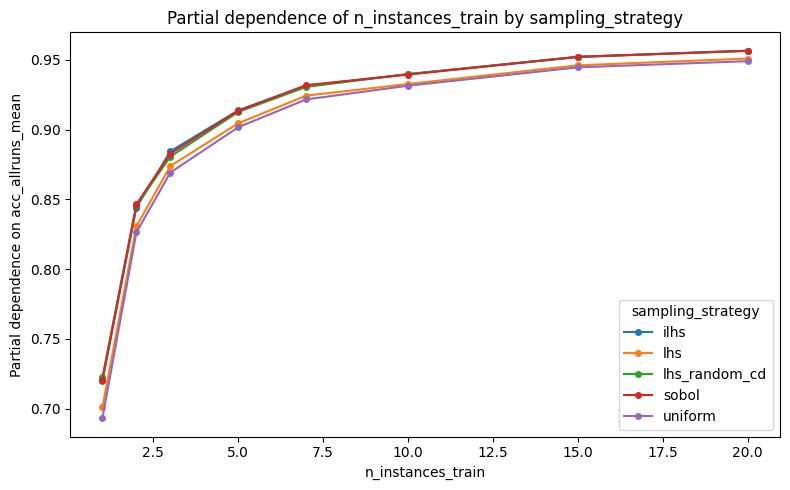

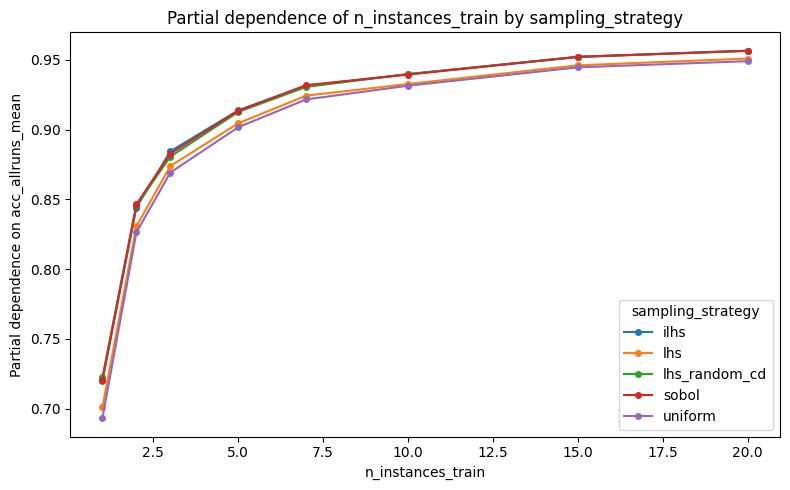

In [21]:
plot_pdp_by_strategy(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_instances_train")

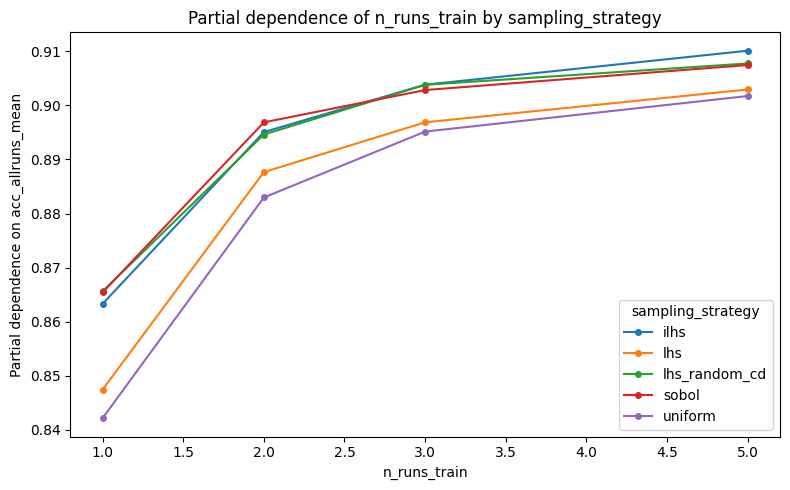

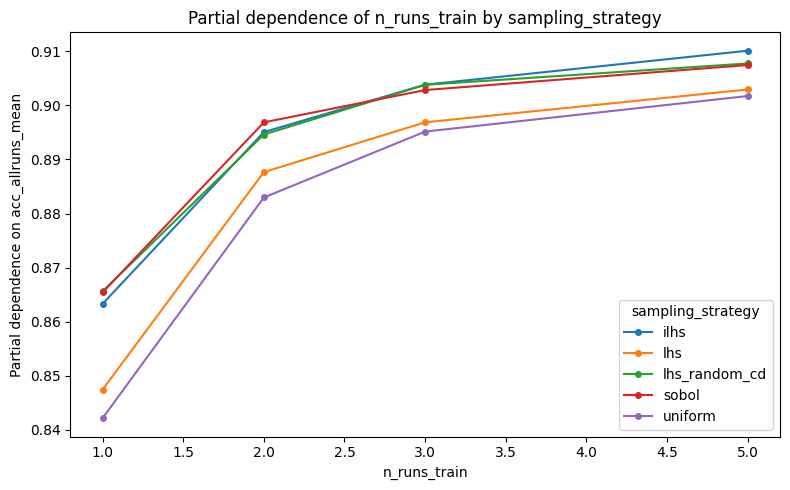

In [22]:
plot_pdp_by_strategy(input_df, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_runs_train")